In [2]:
from IPython.display import display, HTML
display(HTML("""
<style>
div.container{width:90% !important;}
div.cell.code_cell.rendered{width:100%;}
div.input_prompt{padding:0px;}
div.CodeMirror {font-family:Consolas; font-size:20pt;}
.inner_cell{font-size:20pt;}
div.text_cell_render pre code {font-size:20pt; line-height:30px;}
div.output {font-size:20pt; font-weight:bold;}
div.input {font-family:Consolas; font-size:20pt;}
div.prompt {min-width:70px;}
div#toc-wrapper{padding-top:120px;}
div.text_cell_render ul li{font-size:20pt;padding:5px;}
table.dataframe{font-size:20px;}
</style>
"""))

<font size="6" color="red">ch10. N차원 배열 다루기</font>
- N차원 배열 객체 : 동일 자료형의 집합
- 2차원 배열은 행렬개념으로 이해
- [numpy](https://numpy.org)
- [numpy API Docs](https://numpy.org/doc/stable/reference/index.html)
# 1절. 넘파이 패키지

In [4]:
import numpy as np
np.__version__ # tensorflow==2.10과 맞는 numpy 버전

'1.23.5'

In [7]:
# np.arange(from,stop, by) : from부터 stop앞까지 by씩 증가하는 1차원 정수 배열
a = np.arange(15)
print(a.shape) # 15열짜리 1차원 배열
a

(15,)


array([ 0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14])

## 1.1 배열속성

In [55]:
from numpy import arange
a = arange(15, 
          # dtype=np.int8
          ).reshape(3, 5) #3행5열짜리로 변환
a

array([[ 0,  1,  2,  3,  4],
       [ 5,  6,  7,  8,  9],
       [10, 11, 12, 13, 14]])

In [24]:
type(a) # a변수의 타입

numpy.ndarray

In [26]:
a.dtype # a배열의 요소(item)들의 type

dtype('int32')

In [32]:
a.dtype.name

'int32'

In [33]:
a.itemsize # 한 요소(item)의 bytesize

4

In [38]:
a.ndim # 축수(차원수)

2

In [40]:
a.size # 배열 요소의 갯수

15

In [27]:
a.shape # 배열 구조(2차원 3행5열)

(3, 5)

In [56]:
print('shape 조정전 a:\n', a)
a.shape = (5,3)
print('shape 조정후 a:\n', a)

shape 조정전 a:
 [[ 0  1  2  3  4]
 [ 5  6  7  8  9]
 [10 11 12 13 14]]
shape 조정후 a:
 [[ 0  1  2]
 [ 3  4  5]
 [ 6  7  8]
 [ 9 10 11]
 [12 13 14]]


## 1.2 배열 타입 변경

In [57]:
# 배열 요소의 타입변경(X)
a = np.arange(12).reshape(3, 4)
a

array([[ 0,  1,  2,  3],
       [ 4,  5,  6,  7],
       [ 8,  9, 10, 11]])

In [58]:
a.size # 요소갯수

12

In [59]:
a.dtype 

dtype('int32')

In [60]:
a.itemsize

4

In [61]:
a.dtype = np.int64
a.dtype

dtype('int64')

In [62]:
a.itemsize # 요소의 byte수

8

In [54]:
a

array([[ 4294967296, 12884901890],
       [21474836484, 30064771078],
       [38654705672, 47244640266]], dtype=int64)

In [63]:
a.size # 요소수

6

In [64]:
# 배열 요소의 타입변경(O)
a = arange(15).reshape(5,3)
a

array([[ 0,  1,  2],
       [ 3,  4,  5],
       [ 6,  7,  8],
       [ 9, 10, 11],
       [12, 13, 14]])

In [68]:
#a.astype(np.int64) # 출력O->a가 바뀌지 않음. 출력X->a바뀜
a = a.astype(np.int64)
a

array([[ 0,  1,  2],
       [ 3,  4,  5],
       [ 6,  7,  8],
       [ 9, 10, 11],
       [12, 13, 14]], dtype=int64)

In [69]:
a.dtype

dtype('int64')

In [71]:
a.itemsize

8

In [72]:
a

array([[ 0,  1,  2],
       [ 3,  4,  5],
       [ 6,  7,  8],
       [ 9, 10, 11],
       [12, 13, 14]], dtype=int64)

In [75]:
a.ravel() # flaten된 배열을 return

array([ 0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14],
      dtype=int64)

In [76]:
a.flatten() # flaten된 배열을 return

array([ 0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14],
      dtype=int64)

## 1.3 배열 저장
- pkl(객체, 배열, 머신러닝 모델 저장) vs npy(넘파이 전용포맷, io개선)

In [78]:
a

array([[ 0,  1,  2],
       [ 3,  4,  5],
       [ 6,  7,  8],
       [ 9, 10, 11],
       [12, 13, 14]], dtype=int64)

In [85]:
%%time
import time
start = time.time() # 1970.1.1부터 지금까지의 초수
import pickle
with open('data/ch10.pkl', 'wb') as f:
    pickle.dump(a, f)
end = time.time()
print('실행 시간 :', (end-start))

실행 시간 : 0.0
CPU times: total: 0 ns
Wall time: 0 ns


In [86]:
%%time
with open('data/ch10.pkl', 'rb') as f:
    loaded_a = pickle.load(f)

CPU times: total: 0 ns
Wall time: 2.04 ms


In [84]:
# a ==(파일저장)==> 피클파일(269B) ==(load)==> loaded_a
loaded_a

array([[ 0,  1,  2],
       [ 3,  4,  5],
       [ 6,  7,  8],
       [ 9, 10, 11],
       [12, 13, 14]], dtype=int64)

In [87]:
%%time
np.save('data/ch11.npy', a) #넘파이전용포맷. 빠르고 효율적 안전

CPU times: total: 0 ns
Wall time: 1.02 ms


In [88]:
%%time
loaded_a2 = np.load('data/ch11.npy')

CPU times: total: 0 ns
Wall time: 9.14 ms


In [89]:
# a ==(저장)==> npy(248B) ==(load)==> loaded_a2
loaded_a2

array([[ 0,  1,  2],
       [ 3,  4,  5],
       [ 6,  7,  8],
       [ 9, 10, 11],
       [12, 13, 14]], dtype=int64)

# 2절. 넘파이배열
- array()함수를 이용한 다른 파이썬 데이터구조(list, tup)를 배열변환
- 특정값을 갖는 배열 생성함수 : arange, ones, zeros, full, empty.....
- 랜덤값을 갖는 배열 생성함수 ....
- [넘파이함수들](https://numpy.org/doc/stable/reference/index.html)
## 2.1 array()함수로 넘파이 배열 만들기
- array(obj, dtype=np.type, copy=T/F)
- array(obj, dtype='type', copy=T/F)
type 예 : int16, int32, float16, float32, float64,...

In [91]:
a = np.array([2, 14, 6],
             # dtype=np.int16
            ) # 정수의 기본 타입은 int32/실수의 기본타입은 float64
a, a.dtype

(array([ 2, 14,  6]), dtype('int32'))

In [92]:
a[0], a[1], a[2]

(2, 14, 6)

In [93]:
for item in a:
    print(item, end='\t')

2	14	6	

In [96]:
b = np.array([[1.5, 2.3],  # 동일자료형의 집합으로 배열 생성 : 정수>실수>문자
              [4, 5]])     # 실수 배열의 기본타입 : float64
b

array([[1.5, 2.3],
       [4. , 5. ]])

In [97]:
b.dtype

dtype('float64')

In [98]:
l = [[1.5, 2.3],[4, 5]]
l[0][1]

2.3

In [99]:
b[0,1] # 2차원 [axis0=행, axis1=열]  cf. 1차원[axis0=열]

2.3

In [110]:
a = np.array([[1.5, 2.3], 
              [4,5]], 
            # dtype="float32"
             dtype=np.float32
            ).reshape(4)
a

array([1.5, 2.3, 4. , 5. ], dtype=float32)

In [111]:
a.dtype

dtype('float32')

In [112]:
# a의 배열 구조 변경
a.shape = (2,2)
a

array([[1.5, 2.3],
       [4. , 5. ]], dtype=float32)

In [114]:
# a의 dtype(요소의 타입) 변경
# a.dtype = np.float16
a = a.astype(np.float16)
a

array([[1.5, 2.3],
       [4. , 5. ]], dtype=float16)

In [116]:
l = [[1.5, 2.3], 
     [4,5]]
for row in l:
    for item in row:
        print(item, end=' ')
    print()

1.5 2.3 
4 5 


In [119]:
for i, row in enumerate(l):
    for j, item in enumerate(row):
        print(f"{i}행{j}열 : {l[i][j]}", end='\t')
    print()

0행0열 : 1.5	0행1열 : 2.3	
1행0열 : 4	1행1열 : 5	


In [120]:
for row in a:
    for item in row:
        print(item, end=' ')
    print()

1.5 2.3 
4.0 5.0 


In [122]:
for i, row in enumerate(a):
    for j, item in enumerate(row):
        #print(f"{i}행{j}열 : {a[i][j]}", end='\t')
        print(f"{i}행{j}열 : {a[i,j]}", end='\t') # float16은 소숫점이하가 불안정
    print()

0행0열 : 1.5	0행1열 : 2.30078125	
1행0열 : 4.0	1행1열 : 5.0	


In [126]:
print(b[0,-1]) # 인덱싱
# print(b[0,2]) 없는 인덱싱은 에러

2.3


In [131]:
# 슬라이싱 from:stop:by : from부터 stop전까지 by씩 전진. 인덱싱은 음수
b[0:, 1:10] # 0~끝행, 1열부터10전열까지 슬라이싱(행과 열 모두 슬라이싱 2차원 배열)

array([[2.3],
       [5. ]])

In [133]:
b[0, 1:3] # 0행,1열부터3열전까지 슬라이싱(열만 슬라이싱 1차원 배열)

array([2.3])

In [139]:
b = np.array([[1, 2, 3],
              [6, 7, 8]])
# 모든 행의 마지막 열만 추출
b[:, -1:], b[:, -1]

(array([[3],
        [8]]),
 array([3, 8]))

In [141]:
# 모든 행의 마지막 열을 제외한 부분 추출
b[:, :-1]

array([[1, 2],
       [6, 7]])

In [143]:
# 스칼라 변수
a = 10  # 원본
b = a   # 복제본
print("a={}, b={}, a주소={}, b주소={}".format(a, b, id(a), id(b)))
b = -1
print("a={}, b={}, a주소={}, b주소={}".format(a, b, id(a), id(b)))

a=10, b=10, a주소=1883862860304, b주소=1883862860304
a=10, b=-1, a주소=1883862860304, b주소=1883862859952


In [158]:
# numpy 배열
c = np.array([[1, 2], [3, 4]], dtype=np.int8) # 원본
d = np.array(c, copy=False) # d = c 동일 #할당
print("c=", c, sep="\n")
print("d=", c, sep="\n")
print('두 변수의 주소 :', id(c), id(d))
d[0, 0] = 9
print("c=", d, sep="\n")
print("d=", d, sep="\n")
print('두 변수의 주소 :', id(c), id(d))

c=
[[1 2]
 [3 4]]
d=
[[1 2]
 [3 4]]
두 변수의 주소 : 1884005143664 1884005143664
c=
[[9 2]
 [3 4]]
d=
[[9 2]
 [3 4]]
두 변수의 주소 : 1884005143664 1884005143664


In [160]:
# numpy 배열
c = np.array([[1, 2], [3, 4]], dtype=np.int8) # 원본
d = np.array(c, copy=True) # d = c.copy()와 동일 #깊은 복사
print("c=", c, sep="\n")
print("d=", d, sep="\n")
print('두 변수의 주소 :', id(c), id(d))
d[0,0] = 9
print("c=", c, sep="\n")
print("d=", d, sep="\n")
print('두 변수의 주소 :', id(c), id(d))

c=
[[1 2]
 [3 4]]
d=
[[1 2]
 [3 4]]
두 변수의 주소 : 1884005147984 1884005139152
9
c=
[[1 2]
 [3 4]]
d=
[[9 2]
 [3 4]]
두 변수의 주소 : 1884005147984 1884005139152


In [162]:
# copy=False해도 깊은 복사가 되는 경우 : dtype이 바뀌면 자동 깊은 복사
c = np.array([[1, 2], [3, 4]], dtype=np.int8) # 원본
d = np.array(c, copy=False,    dtype=np.int32)
print("c=", c, sep="\n")
print("d=", d, sep="\n")
print('두 변수의 주소 :', id(c), id(d))
d[0,0] = 9
print("c=", c, sep="\n")
print("d=", d, sep="\n")
print('두 변수의 주소 :', id(c), id(d))

c=
[[1 2]
 [3 4]]
d=
[[1 2]
 [3 4]]
두 변수의 주소 : 1884005143568 1884005143184
c=
[[1 2]
 [3 4]]
d=
[[9 2]
 [3 4]]
두 변수의 주소 : 1884005143568 1884005143184


## 2.2 기본값이 있는 배열 만들기
- np.zeros( tup [,dtype] ) : 요소들이 다 0.0
- np.ones( tup [,dtype] ) : 요소들이 다 1.0
- np.full(tup, 기본값) : 요소들이 다 두번째 매개변수인 기본값
- np.empty( tup ) : 초기 내용은 임의의 값인 배열(메모리 상태에 따라 달라짐)

※ 위의 함수를 이용해서 생성된 배열은 기본 dtype이 float64. dtype속성을 따로 지정할 수 있음

In [231]:
np.zeros( (3, 5) ) # 3행5열짜리 2차원 float64 배열(요소들은 다 0)
np.zeros( (5,)   ) # 5열짜리 1차원 float64 배열(요소들은 다 0)
np.zeros( 5 ) # 5열짜리 1차원 float64 배열(요소들은 다 0)

array([0., 0., 0., 0., 0.])

In [234]:
x = np.zeros( (2, 5), dtype=np.bool8)
print(x)
print(x.dtype)
print(x.itemsize)

[[False False False False False]
 [False False False False False]]
bool
1


In [236]:
np.ones( (3, 5) ) # 3행5열짜리 2차원 float64 배열(요소들은 다 1)
np.ones( (5,)   ) # 5열짜리 1차원 float64 배열(요소들은 다 1)
np.ones( 5 ) # 5열짜리 1차원 float64 배열(요소들은 다 1)

array([1., 1., 1., 1., 1.])

In [237]:
x = np.ones( (2, 5), dtype=np.bool8)
print(x)
print(x.dtype)
print(x.itemsize)

[[ True  True  True  True  True]
 [ True  True  True  True  True]]
bool
1


In [241]:
x = np.full( (2,5), 255 )
print(x)
print(x.dtype)

[[255 255 255 255 255]
 [255 255 255 255 255]]
int32


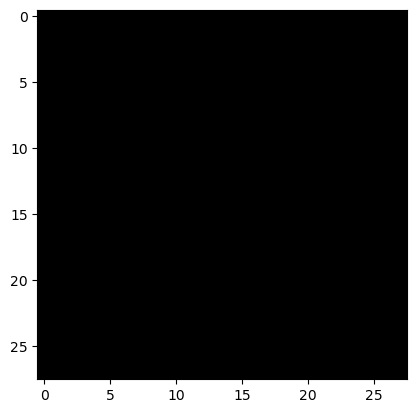

In [261]:
import matplotlib.pyplot as plt
img = np.full( (28,28), 255, dtype=np.uint8) # 하얀색
img = np.full( (28,28), 200, dtype=np.uint8) # 회색
img = np.zeros( (28,28), dtype=np.uint8) # 검정색
#plt.figure(figsize=(1,1))
plt.imshow(img, cmap='gray', vmin=0, vmax=255)
# plt.axis('off')
plt.show()

In [1]:
import numpy as np
np.empty( (3, 2) )

array([[2.44770517e-307, 1.61324815e-307],
       [9.34609790e-307, 4.45036841e-308],
       [1.11261095e-306, 1.22381779e-307]])

## 2.3 랜덤값을 갖는 배열 만들기
- np.random.random( tup ) : 0부터 1미만의 균등분포를 갖은 tup 사이즈 랜덤값
- np.random.uniform(low=0, high=1.0, size=tup) : low부터 high미만까지 균등분포를 갖는 랜덤값
- np.random.normal(loc=0.0, scale=1.0, size=tup) : 평균loc, 표준편차scale을 갖는 정규분포 랜덤값

- np.random.rand(n) : 균등분포의 1차원 0~1미만 난수 배열 발생(난수가 n개)
- np.random.randn(n) : 표준정규분포(평균0, 표준편차가1인 정규분포)의 1차원 난수 배열 발생(난수 n개)

- np.random.randint(n) : 0부터 n미만의 정수 난수 1개발생 == random.randint(0, n-1)
- np.random.randint(from, to) : from부터 to미만의 정수 난수 1개발생 
                    == random.randint(from,to-1)

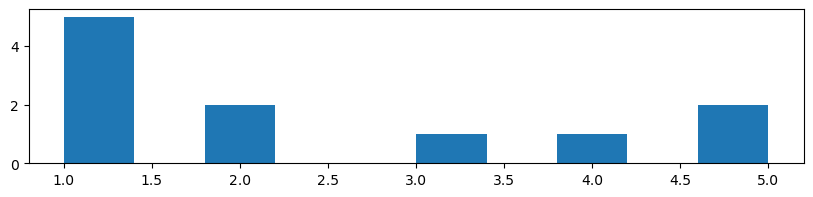

In [31]:
import matplotlib.pyplot as plt
plt.figure(figsize=(10, 2)) # 그래프 사이즈 조절
x = [1, 2, 3, 1, 1, 1, 2, 1, 4, 5, 5]
plt.hist(x, bins=10)
plt.show()

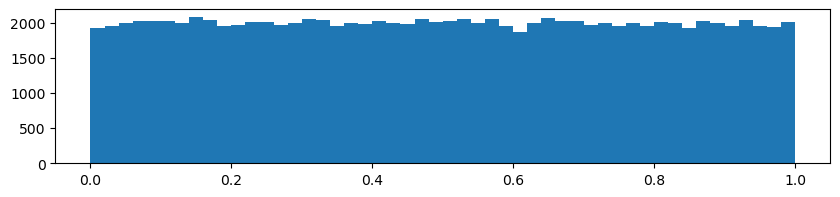

In [49]:
import matplotlib.pyplot as plt
plt.figure(figsize=(10, 2)) # 그래프 사이즈 조절
# x = np.random.random(1000000)
# x = np.random.uniform(1, 10, 10000000)
x = np.random.rand(100000)
plt.hist(x, bins=50)
plt.show()

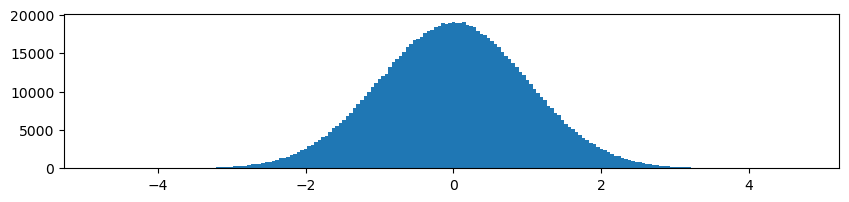

In [63]:
plt.figure(figsize=(10, 2)) # 그래프 사이즈 조절
x = np.random.normal(50, 10, 1000000) # 정규분포
x = np.random.normal(0, 1, 1000000) # 표준정규분포
x = np.random.randn(1000000)# 표준정규분포
plt.hist(x, bins=200)
plt.show()

# 4절. 복사와 뷰
## 4.1 할당

In [164]:
# 스칼라 변수
a = 10
b = a
print('a와 b주소 :', id(a), id(b))
b = 99
print('수정 후 a와 b주소 :', id(a), id(b))
print('수정 후 a와 b 데이터 :', a, b)

a와 b주소 : 1883862860304 1883862860304
수정 후 a와 b주소 : 1883862860304 1883862863152
수정 후 a와 b 데이터 : 10 99


In [166]:
# 배열
a = np.arange(12)
a

array([ 0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11])

In [167]:
b = a
# b = np.array(a, copy=False)와 같음
a.shape, type(a), a.ndim, id(a)

((12,), numpy.ndarray, 1, 1884003726512)

In [168]:
b.shape, type(b), b.ndim, id(b)

((12,), numpy.ndarray, 1, 1884003726512)

In [169]:
a is b

True

In [170]:
a == b # 요소별 비교

array([ True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True])

In [172]:
np.all(a==b) # np.all() array배열 안의 모든 값이 True인지 여부

True

In [173]:
b.shape = (3, 4)

In [174]:
b.shape, type(b), b.ndim, id(b)

((3, 4), numpy.ndarray, 2, 1884003726512)

In [176]:
a.shape

(3, 4)

In [177]:
a

array([[ 0,  1,  2,  3],
       [ 4,  5,  6,  7],
       [ 8,  9, 10, 11]])

## 4.2 뷰(View) : 얕은 복사

In [178]:
a = np.arange(12).reshape(3, 4)
a

array([[ 0,  1,  2,  3],
       [ 4,  5,  6,  7],
       [ 8,  9, 10, 11]])

In [179]:
c = a.view() # 얕은 복사
c

array([[ 0,  1,  2,  3],
       [ 4,  5,  6,  7],
       [ 8,  9, 10, 11]])

In [180]:
id(a), id(c)

(1884005150000, 1884005147024)

In [185]:
a==c

array([[ True,  True,  True,  True],
       [ True,  True,  True,  True],
       [ True,  True,  True,  True]])

In [186]:
np.all(a==c)

True

In [187]:
a is c

False

In [190]:
c.shape = (2, 6)
c

array([[ 0,  1,  2,  3,  4,  5],
       [ 6,  7,  8,  9, 10, 11]])

In [191]:
a

array([[ 0,  1,  2,  3],
       [ 4,  5,  6,  7],
       [ 8,  9, 10, 11]])

In [193]:
# 배열 복사본 c의 특정 요소만 변경
c[1,::2] = -99
c

array([[  0,   1,   2,   3,   4,   5],
       [-99,   7, -99,   9, -99,  11]])

In [194]:
a

array([[  0,   1,   2,   3],
       [  4,   5, -99,   7],
       [-99,   9, -99,  11]])

In [209]:
# 슬라이싱이 될 때 뷰가 반환됨(shape과 dtype변경외는 원본도 변경)
a = np.array([[99, 88, 77, 85],
              [88, 71, 77, 77],
              [99, 99, 99, 99],])
a

array([[99, 88, 77, 85],
       [88, 71, 77, 77],
       [99, 99, 99, 99]])

In [210]:
X = a[:, :-1]
X

array([[99, 88, 77],
       [88, 71, 77],
       [99, 99, 99]])

In [211]:
X[0:2, -1] = 1
X[-1, -1] = -1
X

array([[99, 88,  1],
       [88, 71,  1],
       [99, 99, -1]])

In [212]:
a

array([[99, 88,  1, 85],
       [88, 71,  1, 77],
       [99, 99, -1, 99]])

## 4.3 깊은 복사

In [213]:
# 슬라이싱이 될 때 뷰가 반환됨(shape과 dtype변경외는 원본도 변경)
a = np.array([[99, 88, 77, 85],
              [88, 71, 77, 77],
              [99, 99, 99, 99],])
a

array([[99, 88, 77, 85],
       [88, 71, 77, 77],
       [99, 99, 99, 99]])

In [214]:
#X = a[:, :-1] # 얕은 복사(view생성)
X = a[:, :-1].copy() # 깊은 복사
# X = np.array(a[:, :-1], copy=True) # 깊은 복사

In [215]:
X[:, 0:2] = 1
X[-1, -1] = -1
X

array([[ 1,  1, 77],
       [ 1,  1, 77],
       [ 1,  1, -1]])

In [216]:
a

array([[99, 88, 77, 85],
       [88, 71, 77, 77],
       [99, 99, 99, 99]])